In [23]:
print("Data Exploration Notebook")

Data Exploration Notebook


# Importing library

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

# Load Raw Data

In [25]:
DATA_PATH = "../data/raw/HHS_Unaccompanied_Alien_Children_Program.csv"
df = pd.read_csv(DATA_PATH)

# First Look at Data

In [26]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


In [27]:
df.tail()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
1165,NaN,NaN,NaN,NaN,NaN,NaN
1166,NaN,NaN,NaN,NaN,NaN,NaN
1167,NaN,NaN,NaN,NaN,NaN,NaN
1168,NaN,NaN,NaN,NaN,NaN,NaN
1169,NaN,NaN,NaN,NaN,NaN,NaN


In [28]:
df.sample(10)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
745,NaN,NaN,NaN,NaN,NaN,NaN
1116,NaN,NaN,NaN,NaN,NaN,NaN
162,"April 17, 2025",7.0,26.0,10.0,"2,288",14.0
785,NaN,NaN,NaN,NaN,NaN,NaN
855,NaN,NaN,NaN,NaN,NaN,NaN
923,NaN,NaN,NaN,NaN,NaN,NaN
558,"September 19, 2023",133.0,287.0,189.0,"11,095",260.0
702,"February 14, 2023",154.0,225.0,220.0,"7,794",223.0
845,NaN,NaN,NaN,NaN,NaN,NaN
186,"March 17, 2025",5.0,14.0,0.0,"2,111",8.0


# Shape & Columns

In [29]:
print("Rows, Columns:", df.shape)
print("\nColumns:")
df.columns

Rows, Columns: (1170, 6)

Columns:


Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')

# Data Types Check

In [30]:
df.dtypes

Date                                                object
Children apprehended and placed in CBP custody*    float64
Children in CBP custody                            float64
Children transferred out of CBP custody            float64
Children in HHS Care                                object
Children discharged from HHS Care                  float64
dtype: object

# Basic Summary Statistics

In [31]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


# Check Missing Values

In [32]:
df.isnull().sum()

Date                                               450
Children apprehended and placed in CBP custody*    450
Children in CBP custody                            450
Children transferred out of CBP custody            450
Children in HHS Care                               450
Children discharged from HHS Care                  450
dtype: int64

# Convert Date Column

In [33]:
df["Date"] = pd.to_datetime(df["Date"])

In [34]:
print("Start Date:", df["Date"].min())
print("End Date:", df["Date"].max())
print("Total Days:", df["Date"].nunique())

Start Date: 2023-01-12 00:00:00
End Date: 2025-12-21 00:00:00
Total Days: 720


# Sort by Date

In [35]:
df = df.sort_values("Date").reset_index(drop=True)

# Quick Visual – System Load Intuition

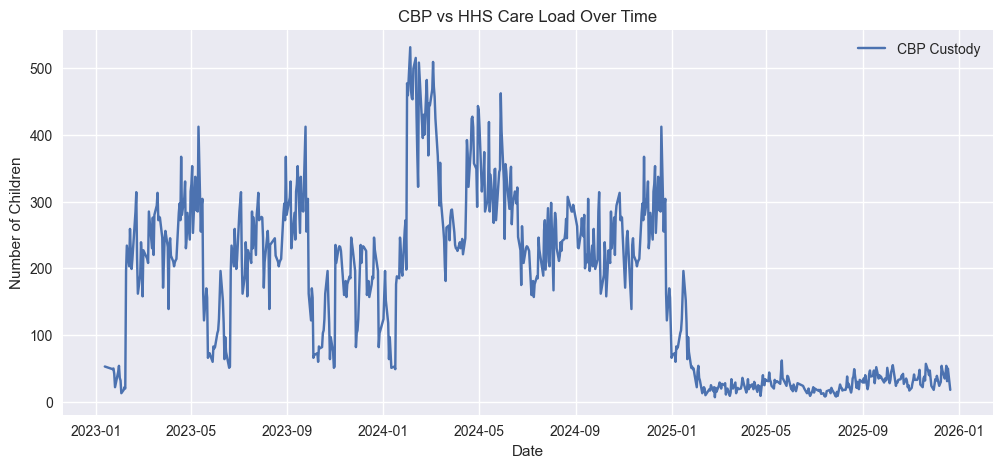

In [39]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Children in CBP custody"], label="CBP Custody")
plt.title("CBP vs HHS Care Load Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Children")
plt.legend()
plt.show()

# Daily Intake vs Discharge (Intuition)

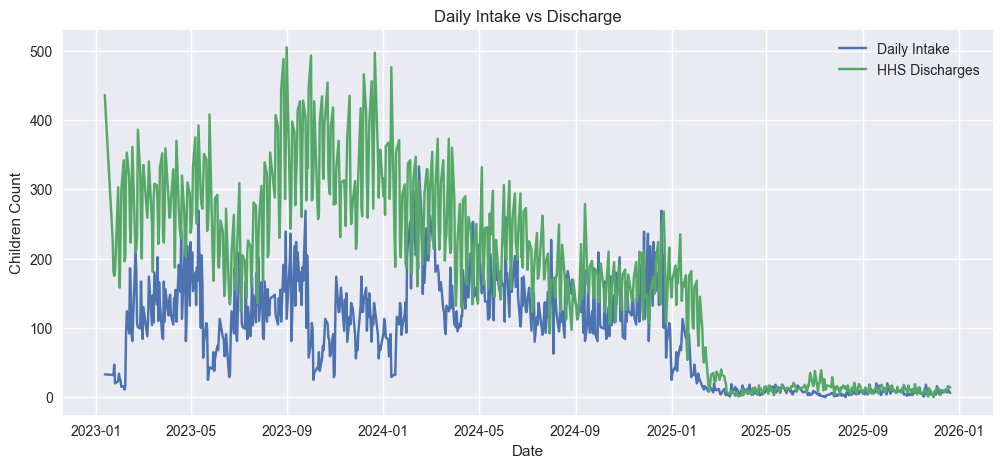

In [40]:
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Children apprehended and placed in CBP custody*"], label="Daily Intake")
plt.plot(df["Date"], df["Children discharged from HHS Care"], label="HHS Discharges")
plt.title("Daily Intake vs Discharge")
plt.xlabel("Date")
plt.ylabel("Children Count")
plt.legend()
plt.show()

Key Observations

### Initial Observations

- CBP and HHS care loads show significant temporal variation.
- Periods where intake exceeds discharge suggest potential backlog.
- Further validation is required for logical constraints and missing dates.
